In [1]:
!pip install timm -q

In [2]:
!pip uninstall -y kaggle kagglesdk requests urllib3 -q
!pip install requests==2.32.4 -q
!pip install kaggle -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 10.9 MB/s eta 0:00:00


In [3]:
import os
import json

kaggle_creds = {"username": "deonasaji", "key": "KGAT_e48eb4132db7726c40438655aa2c2cf4"}
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)
!chmod 600 /root/.kaggle/kaggle.json
os.environ["KAGGLE_API_TOKEN"] = kaggle_creds["key"]

import kaggle
kaggle.KaggleApi().authenticate()
print("✅ Kaggle ready")

✅ Kaggle ready


In [4]:
!kaggle competitions download -c paddy-disease-classification -q
import zipfile
!mkdir -p paddy_data
with zipfile.ZipFile('paddy-disease-classification.zip', 'r') as z:
    z.extractall('paddy_data')
!ls paddy_data

sample_submission.csv  test_images  train.csv  train_images


In [5]:
import os, gc, random, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
import timm

warnings.filterwarnings('ignore')

SEED       = 42
DATA_DIR   = Path('/content/paddy_data')
TRAIN_DIR  = DATA_DIR / 'train_images'
TEST_DIR   = DATA_DIR / 'test_images'
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if DEVICE=="cuda" else "None"}')

Device: cuda
GPU: Tesla T4


In [6]:
# ── Data ─────────────────────────────────────────────────────────
df = pd.read_csv(DATA_DIR / 'train.csv')
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
NUM_CLASSES = df['label_enc'].nunique()

train_df, val_df = train_test_split(
    df, test_size=0.1, stratify=df['label_enc'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Classes: {NUM_CLASSES}')

Train: 9366 | Val: 1041 | Classes: 10


In [7]:
# ── Dataset ───────────────────────────────────────────────────────
class PaddyDataset(Dataset):
    def __init__(self, df, img_dir, transform, is_test=False):
        self.df       = df
        self.img_dir  = img_dir
        self.transform= transform
        self.is_test  = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.is_test:
            path = self.img_dir / row['image_id']
        else:
            path = self.img_dir / row['label'] / row['image_id']
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        if self.is_test:
            return img, row['image_id']
        return img, int(row['label_enc'])


MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def train_tfm(size):
    return T.Compose([
        T.RandomResizedCrop(size, scale=(0.7, 1.0)),
        T.RandomHorizontalFlip(),
        T.RandomVerticalFlip(),
        T.ColorJitter(0.3, 0.3, 0.2, 0.1),
        T.RandomRotation(15),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])

def val_tfm(size):
    return T.Compose([
        T.Resize((size, size)),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])

In [8]:
# ── Train / Val helpers ───────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, scaler, scheduler):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()          # ← per-batch (correct for OneCycleLR)
        loss_sum += loss.item() * labels.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += labels.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def val_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        with autocast():
            out  = model(imgs)
            loss = criterion(out, labels)
        loss_sum += loss.item() * labels.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += labels.size(0)
    return loss_sum / total, correct / total

In [9]:
# ── STAGE 1: Train head only (fast warm-up) ───────────────────────
IMG1, BS1, EPOCHS1, LR1 = 224, 64, 6, 3e-4

model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# Freeze backbone, only train classifier
for name, p in model.named_parameters():
    p.requires_grad = ('classifier' in name)

print(f'Stage 1 trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

train_ds1 = PaddyDataset(train_df, TRAIN_DIR, train_tfm(IMG1))
val_ds1   = PaddyDataset(val_df,   TRAIN_DIR, val_tfm(IMG1))
train_ld1 = DataLoader(train_ds1, batch_size=BS1, shuffle=True,  num_workers=2, pin_memory=True)
val_ld1   = DataLoader(val_ds1,   batch_size=BS1*2, shuffle=False, num_workers=2, pin_memory=True)

optimizer1  = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR1, weight_decay=1e-4)
scheduler1  = optim.lr_scheduler.OneCycleLR(optimizer1, max_lr=LR1,
                  steps_per_epoch=len(train_ld1), epochs=EPOCHS1, pct_start=0.3)
criterion   = nn.CrossEntropyLoss(label_smoothing=0.05)
scaler      = GradScaler()

best_acc = 0.0
print(f'\n--- Stage 1: Head only | {IMG1}px | {EPOCHS1} epochs ---')
for ep in range(1, EPOCHS1+1):
    tr_loss, tr_acc = train_epoch(model, train_ld1, optimizer1, criterion, scaler, scheduler1)
    vl_loss, vl_acc = val_epoch(model, val_ld1, criterion)
    tag = ''
    if vl_acc > best_acc:
        best_acc = vl_acc
        torch.save(model.state_dict(), '/content/best_model.pth')
        tag = ' ← best'
    print(f'Ep {ep:02d}/{EPOCHS1} | tr_loss {tr_loss:.4f} tr_acc {tr_acc:.4f} | val_loss {vl_loss:.4f} val_acc {vl_acc:.4f}{tag}')

print(f'\n✅ Stage 1 best val acc: {best_acc:.4f}')

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Stage 1 trainable: 15,370

--- Stage 1: Head only | 224px | 6 epochs ---
Ep 01/6 | tr_loss 3.3370 tr_acc 0.1460 | val_loss 3.1622 val_acc 0.1575 ← best
Ep 02/6 | tr_loss 2.8795 tr_acc 0.1855 | val_loss 2.8114 val_acc 0.1969 ← best
Ep 03/6 | tr_loss 2.6384 tr_acc 0.2306 | val_loss 2.5795 val_acc 0.2344 ← best
Ep 04/6 | tr_loss 2.4648 tr_acc 0.2659 | val_loss 2.4947 val_acc 0.2546 ← best
Ep 05/6 | tr_loss 2.3959 tr_acc 0.2685 | val_loss 2.4474 val_acc 0.2622 ← best
Ep 06/6 | tr_loss 2.3712 tr_acc 0.2782 | val_loss 2.4338 val_acc 0.2680 ← best

✅ Stage 1 best val acc: 0.2680


In [10]:
# ── STAGE 2: Unfreeze all, larger resolution ──────────────────────
IMG2, BS2, EPOCHS2, LR2 = 320, 32, 8, 5e-5

# Load best from stage 1, unfreeze everything
model.load_state_dict(torch.load('/content/best_model.pth'))
for p in model.parameters():
    p.requires_grad = True

print(f'Stage 2 trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

train_ds2 = PaddyDataset(train_df, TRAIN_DIR, train_tfm(IMG2))
val_ds2   = PaddyDataset(val_df,   TRAIN_DIR, val_tfm(IMG2))
train_ld2 = DataLoader(train_ds2, batch_size=BS2, shuffle=True,  num_workers=2, pin_memory=True)
val_ld2   = DataLoader(val_ds2,   batch_size=BS2*2, shuffle=False, num_workers=2, pin_memory=True)

optimizer2 = optim.AdamW(model.parameters(), lr=LR2, weight_decay=1e-4)
scheduler2 = optim.lr_scheduler.OneCycleLR(optimizer2, max_lr=LR2,
                 steps_per_epoch=len(train_ld2), epochs=EPOCHS2, pct_start=0.1)
scaler2    = GradScaler()

best_acc2 = 0.0
print(f'\n--- Stage 2: Full fine-tune | {IMG2}px | {EPOCHS2} epochs ---')
for ep in range(1, EPOCHS2+1):
    tr_loss, tr_acc = train_epoch(model, train_ld2, optimizer2, criterion, scaler2, scheduler2)
    vl_loss, vl_acc = val_epoch(model, val_ld2, criterion)
    tag = ''
    if vl_acc > best_acc2:
        best_acc2 = vl_acc
        torch.save(model.state_dict(), '/content/best_model.pth')
        tag = ' ← best'
    print(f'Ep {ep:02d}/{EPOCHS2} | tr_loss {tr_loss:.4f} tr_acc {tr_acc:.4f} | val_loss {vl_loss:.4f} val_acc {vl_acc:.4f}{tag}')

print(f'\n✅ Stage 2 best val acc: {best_acc2:.4f}')

Stage 2 trainable: 10,711,602

--- Stage 2: Full fine-tune | 320px | 8 epochs ---
Ep 01/8 | tr_loss 1.8844 tr_acc 0.3991 | val_loss 1.4304 val_acc 0.5725 ← best
Ep 02/8 | tr_loss 1.1874 tr_acc 0.6565 | val_loss 0.9002 val_acc 0.7752 ← best
Ep 03/8 | tr_loss 0.8827 tr_acc 0.7809 | val_loss 0.7430 val_acc 0.8444 ← best
Ep 04/8 | tr_loss 0.7243 tr_acc 0.8455 | val_loss 0.6370 val_acc 0.8828 ← best
Ep 05/8 | tr_loss 0.6399 tr_acc 0.8822 | val_loss 0.6089 val_acc 0.8972 ← best
Ep 06/8 | tr_loss 0.5919 tr_acc 0.9034 | val_loss 0.5886 val_acc 0.9049 ← best
Ep 07/8 | tr_loss 0.5716 tr_acc 0.9107 | val_loss 0.5778 val_acc 0.9087 ← best
Ep 08/8 | tr_loss 0.5611 tr_acc 0.9155 | val_loss 0.5767 val_acc 0.9068

✅ Stage 2 best val acc: 0.9087


In [11]:
# ── Quick sanity check: peek at val predictions ───────────────────
model.load_state_dict(torch.load('/content/best_model.pth'))
model.eval()

imgs, labels = next(iter(val_ld2))
with torch.no_grad(), autocast():
    preds = model(imgs.to(DEVICE)).argmax(1).cpu()

print('Sample predictions vs ground truth:')
for p, l in zip(preds[:10], labels[:10]):
    print(f'  pred: {le.classes_[p]:<30} true: {le.classes_[l]}')

Sample predictions vs ground truth:
  pred: normal                         true: normal
  pred: blast                          true: blast
  pred: bacterial_leaf_blight          true: downy_mildew
  pred: dead_heart                     true: dead_heart
  pred: normal                         true: normal
  pred: normal                         true: normal
  pred: bacterial_leaf_streak          true: blast
  pred: normal                         true: normal
  pred: tungro                         true: tungro
  pred: dead_heart                     true: dead_heart


In [12]:
# ── Inference & Submission ────────────────────────────────────────
sub_df   = pd.read_csv(DATA_DIR / 'sample_submission.csv')
test_ds  = PaddyDataset(sub_df, TEST_DIR, val_tfm(IMG2), is_test=True)
test_ld  = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

model.load_state_dict(torch.load('/content/best_model.pth'))
model.eval()

all_ids, all_preds = [], []
with torch.no_grad():
    for imgs, ids in test_ld:
        with autocast():
            preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_ids.extend(ids)

submission = pd.DataFrame({'image_id': all_ids, 'label': le.inverse_transform(all_preds)})
submission.to_csv('/content/submission.csv', index=False)
print('Saved submission.csv')
print(submission['label'].value_counts())

Saved submission.csv
label
normal                      670
blast                       556
hispa                       499
dead_heart                  478
tungro                      377
brown_spot                  292
downy_mildew                193
bacterial_leaf_blight       148
bacterial_leaf_streak       141
bacterial_panicle_blight    115
Name: count, dtype: int64


Upload an image (from test_images OR train_images):


Saving 100145.jpg to 100145.jpg


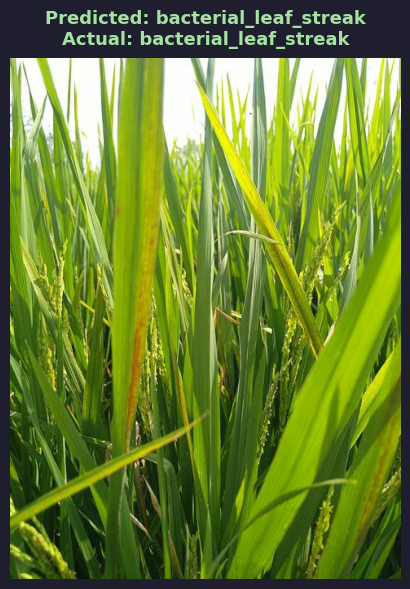

In [14]:
# ── Upload & Predict ──────────────────────────────────────────────
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch, torchvision.transforms as T
from torch.cuda.amp import autocast
import ipywidgets as widgets
from IPython.display import display, clear_output

def predict_image(img_path, true_label=None):
    tfm = T.Compose([
        T.Resize((320, 320)),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    img = Image.open(img_path).convert('RGB')
    inp = tfm(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad(), autocast():
        probs = torch.softmax(model(inp), dim=1)[0]

    top3_probs, top3_idx = probs.topk(3)
    pred_label = le.classes_[top3_idx[0]]

    # ── Plot ──────────────────────────────────────────────────────

    fig, ax1 = plt.subplots(figsize=(6, 6))   # only ONE axis
    fig.patch.set_facecolor('#1e1e2e')

    # Image
    ax1.imshow(img)
    ax1.axis('off')

    correct = (true_label == pred_label) if true_label else None
    color   = '#a6e3a1' if correct else '#f38ba8' if correct is False else '#cdd6f4'

    ax1.set_title(
        f"Predicted: {pred_label}" + (f"\nActual: {true_label}" if true_label else ""),
        color=color, fontsize=13, fontweight='bold', pad=10
    )

    plt.tight_layout()
    plt.show()


# ── Upload & run ──────────────────────────────────────────────────
print("Upload an image (from test_images OR train_images):")
uploaded = files.upload()

for fname in uploaded:
    # Auto-detect true label if it's a training image
    match = train_df[train_df['image_id'] == fname]
    true_label = match.iloc[0]['label'] if len(match) else None

    import tempfile
    with tempfile.NamedTemporaryFile(suffix='.jpg', delete=False) as f:
        f.write(uploaded[fname])
        predict_image(f.name, true_label=true_label)

In [16]:
# ── Save model + label encoder + config, then download ────────────
import pickle, json
from google.colab import files

# 1. Save model weights
torch.save(model.state_dict(), '/content/paddy_model.pth')

# 2. Save label encoder
with open('/content/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# 3. Save config (anything needed to rebuild model)
config = {
    'model_name' : 'efficientnet_b3',
    'num_classes': NUM_CLASSES,
    'img_size'   : 320,
    'classes'    : list(le.classes_),
}
with open('/content/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Files saved:')
print('  paddy_model.pth      ← model weights')
print('  label_encoder.pkl    ← label encoder')
print('  model_config.json    ← class names & config')

# 4. Download all 3
for fname in ['paddy_model.pth', 'label_encoder.pkl', 'model_config.json']:
    files.download(f'/content/{fname}')

Files saved:
  paddy_model.pth      ← model weights
  label_encoder.pkl    ← label encoder
  model_config.json    ← class names & config


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
!pip install gradio -q

✅ Validation Accuracy: 90.87%

                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.77      0.85      0.81        48
   bacterial_leaf_streak       0.90      0.95      0.92        38
bacterial_panicle_blight       0.94      0.85      0.89        34
                   blast       0.92      0.88      0.90       174
              brown_spot       0.91      0.88      0.89        97
              dead_heart       1.00      0.99      0.99       144
            downy_mildew       0.82      0.82      0.82        62
                   hispa       0.97      0.87      0.92       159
                  normal       0.88      0.98      0.92       176
                  tungro       0.87      0.90      0.88       109

                accuracy                           0.91      1041
               macro avg       0.90      0.90      0.90      1041
            weighted avg       0.91      0.91      0.91      1041



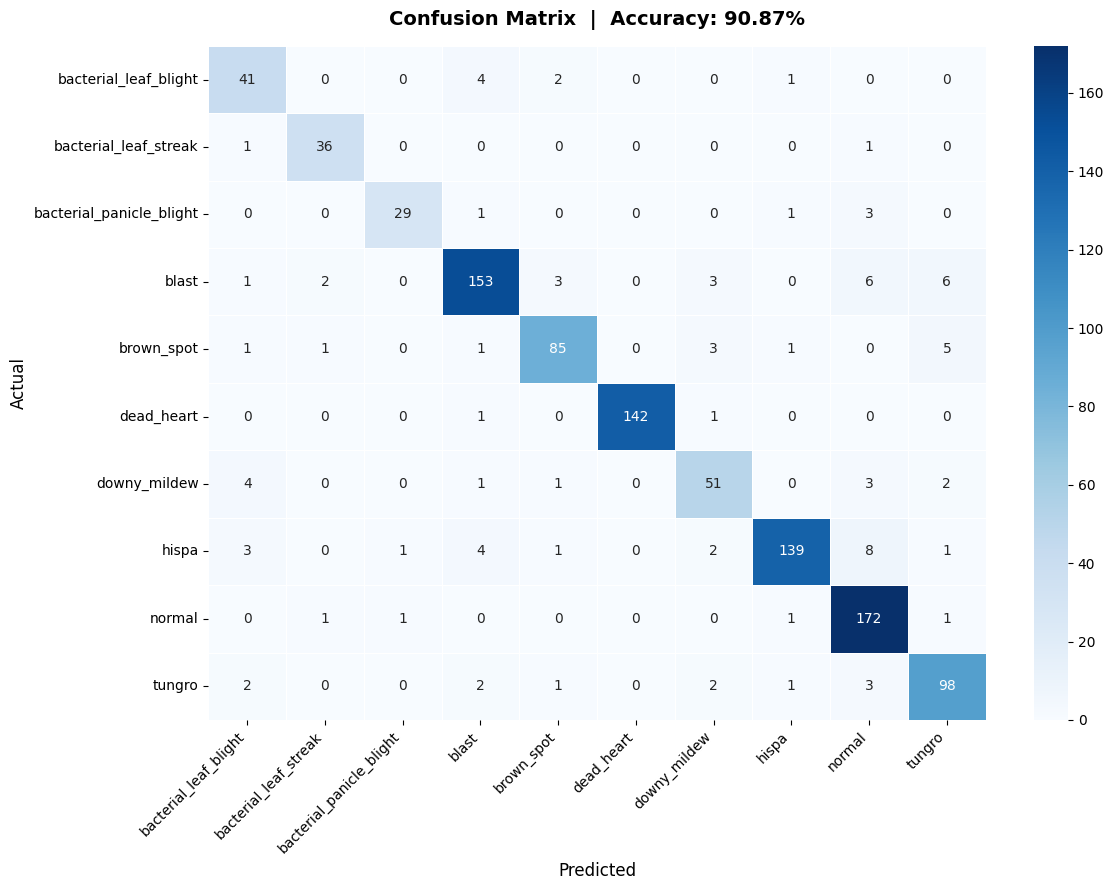

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# ── Get all val predictions ───────────────────────────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_ld2:
        with autocast():
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
acc        = (all_preds == all_labels).mean() * 100
print(f"✅ Validation Accuracy: {acc:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# ── Confusion matrix ──────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5)
plt.title(f'Confusion Matrix  |  Accuracy: {acc:.2f}%', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
import gradio as gr
import torch, timm, json, pickle
from PIL import Image
import torchvision.transforms as T
from torch.cuda.amp import autocast

# ── Load ──────────────────────────────────────────────────────────
with open('model_config.json') as f:
    cfg = json.load(f)
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = timm.create_model(cfg['model_name'], pretrained=False, num_classes=cfg['num_classes'])
model.load_state_dict(torch.load('paddy_model.pth', map_location=DEVICE))
model  = model.to(DEVICE)
model.eval()

# ── Disease info ──────────────────────────────────────────────────
DISEASE_INFO = {
    "bacterial_leaf_blight"   : ("💧", "Water-soaked to yellowish stripe on leaf margins."),
    "bacterial_leaf_streak"   : ("💧", "Dark brown streaks with wavy margins on leaves."),
    "bacterial_panicle_blight": ("💧", "Grain discoloration & panicle sterility."),
    "blast"                   : ("🍄", "Diamond-shaped lesions with gray centers."),
    "brown_spot"              : ("🟤", "Circular brown spots with yellow halo."),
    "dead_heart"              : ("☠️", "Central shoot dies, caused by stem borers."),
    "downy_mildew"            : ("🌫️", "Yellowish patches, white fungal growth below."),
    "hispa"                   : ("🐛", "White blotches caused by leaf mining larvae."),
    "normal"                  : ("✅", "Healthy paddy plant, no disease detected."),
    "tungro"                  : ("🟡", "Yellow-orange discoloration, stunted growth."),
}

# ── Predict ───────────────────────────────────────────────────────
def predict(img):
    if img is None:
        return ""
    tfm = T.Compose([
        T.Resize((cfg['img_size'], cfg['img_size'])),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    inp = tfm(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad(), autocast():
        probs = torch.softmax(model(inp), dim=1)[0]

    top_cls  = le.classes_[probs.argmax().item()]
    emoji, desc = DISEASE_INFO.get(top_cls, ("🌾", ""))
    name     = top_cls.replace('_', ' ').title()
    return f"## {emoji} {name}\n{desc}"

# ── UI ────────────────────────────────────────────────────────────
with gr.Blocks(theme=gr.themes.Soft(), title="Rice Disease Classifier") as demo:
    gr.Markdown("# 🌾 Paddy Disease Classifier")
    with gr.Row():
        img_input = gr.Image(type='pil', label="Upload Paddy Image")
        result    = gr.Markdown()

    img_input.change(fn=predict, inputs=img_input, outputs=result)
    gr.Button("🔍 Classify", variant="primary").click(fn=predict, inputs=img_input, outputs=result)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://807c5f707d46fc4fb2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
